/var/folders/27/jyg7cnqs4cx51q4pg6d2k5400000gn/T/ipykernel_3918/121635772.py:31: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date_indices = pd.date_range(start, end, freq="M")


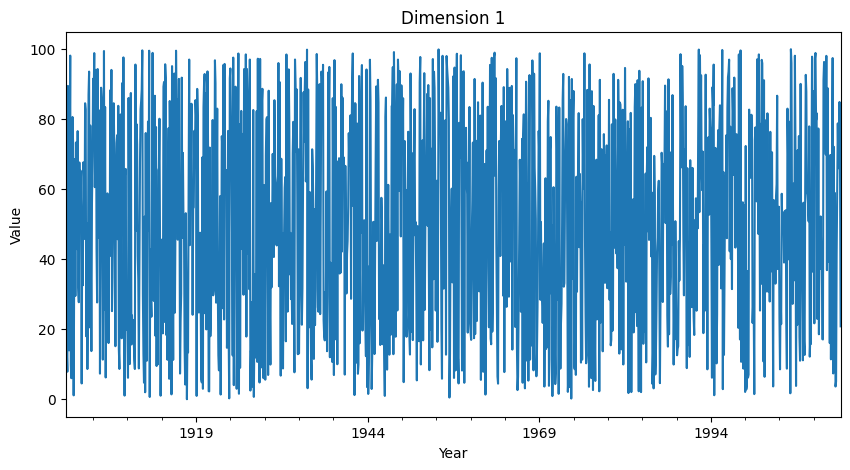

/var/folders/27/jyg7cnqs4cx51q4pg6d2k5400000gn/T/ipykernel_3918/121635772.py:31: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date_indices = pd.date_range(start, end, freq="M")


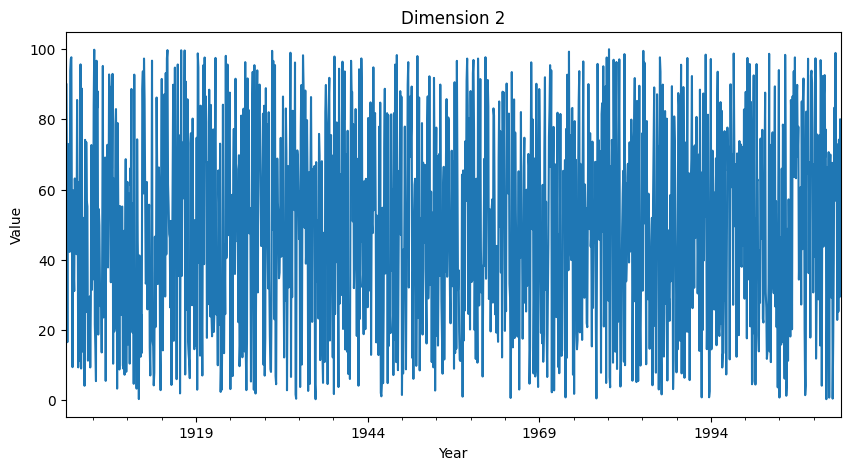

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

data = []

for year in range(1900, 2013):
    for month in range(1, 13):
        dim1 = np.random.uniform(0, 100)
        dim2 = np.random.uniform(0, 100)
        data.append([year, month, dim1, dim2])

data = np.array(data)

# Function to convert year and month into Pandas date
to_date = lambda x, y: str(int(x)) + "-" + str(int(y))

# Function to read one column as time series
def read_data(input_data, index):
    start = to_date(input_data[0, 0], input_data[0, 1])

    if input_data[-1, 1] == 12:
        year = input_data[-1, 0] + 1
        month = 1
    else:
        year = input_data[-1, 0]
        month = input_data[-1, 1] + 1

    end = to_date(year, month)

    date_indices = pd.date_range(start, end, freq="M")
    output = pd.Series(input_data[:, index], index=date_indices)

    return output

# Columns to convert into time-series data
indices = [2, 3]

# Plot both dimensions separately
for index in indices:
    timeseries = read_data(data, index)

    plt.figure(figsize=(10, 5))
    timeseries.plot()
    plt.title("Dimension " + str(index - 1))
    plt.xlabel("Year")
    plt.ylabel("Value")
    plt.show()